In [ ]:
!pip install prophet

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error

from prophet import Prophet

In [ ]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving oil_prices_2426.csv to oil_prices_2426.csv


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("oil_prices_2426.csv")

# Convert date column correctly
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Rename price column
df = df.rename(columns={'price (dollars)': 'price'})

# Sort by date
df = df.sort_values('date')

# Set date as index
df.set_index('date', inplace=True)

print(df.head())

            price
date             
2024-09-21  32.10
2024-09-22  32.25
2024-09-23  31.07
2024-09-24  31.50
2024-09-25  32.21


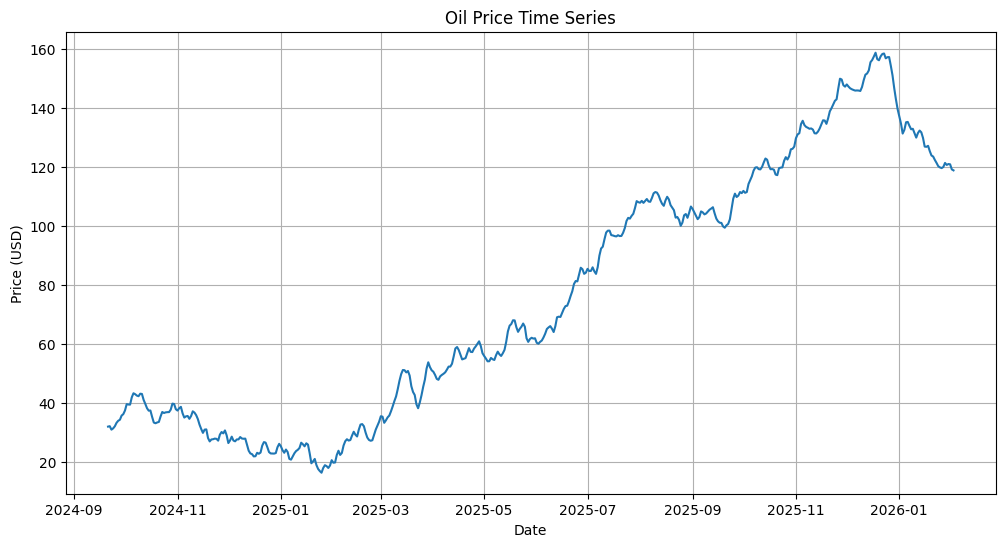

In [ ]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(12,6))
plt.plot(df.index, df['price'])
plt.title("Oil Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid()
plt.show()

In [ ]:
# Summary Statistics
print(df.describe())

            price
count  500.000000
mean    75.873980
std     42.912398
min     16.480000
25%     35.372500
50%     64.290000
75%    111.572500
max    158.780000


In [ ]:
# Stationarity Test (ADF)
result = adfuller(df['price'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is NOT Stationary")

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068
Data is NOT Stationary


<Figure size 1000x500 with 0 Axes>

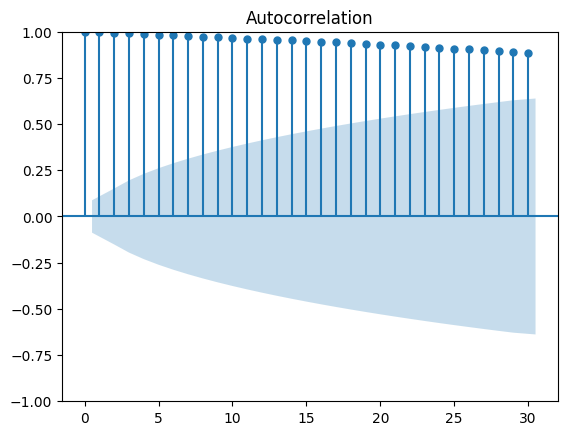

<Figure size 1000x500 with 0 Axes>

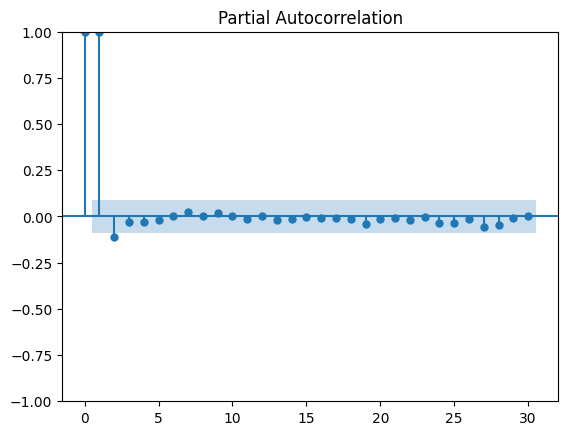

In [ ]:
# ACF and PACF Plots
plt.figure(figsize=(10,5))
plot_acf(df['price'], lags=30)
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(df['price'], lags=30)
plt.show()

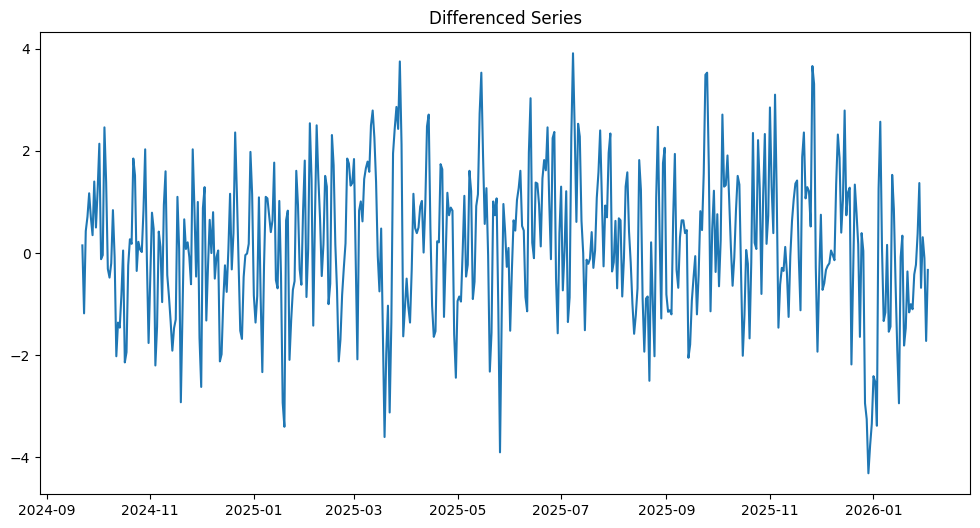

In [ ]:
# Differencing
df['diff_price'] = df['price'].diff()

plt.figure(figsize=(12,6))
plt.plot(df['diff_price'])
plt.title("Differenced Series")
plt.show()

In [ ]:
# ARMA / ARIMA Model Parameter Search
best_aic = np.inf
best_order = None
best_model = None

for p in range(0,9):
    for d in range(0,3):
        for q in range(0,9):
            try:
                model = sm.tsa.ARIMA(df['price'], order=(p,d,q))
                result = model.fit()

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = (p,d,q)
                    best_model = result
            except:
                continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA order: (2, 2, 7)
Best AIC: 1429.357098586032


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Model Summary
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.679
Date:                Sat, 07 Mar 2026   AIC                           1429.357
Time:                        11:36:19   BIC                           1471.463
Sample:                    09-21-2024   HQIC                          1445.882
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1824      0.032    -36.884      0.000      -1.245      -1.120
ar.L2         -0.9175      0.032    -28.331      0.000      -0.981      -0.854
ma.L1          1.1486      0.339      3.390      0.0

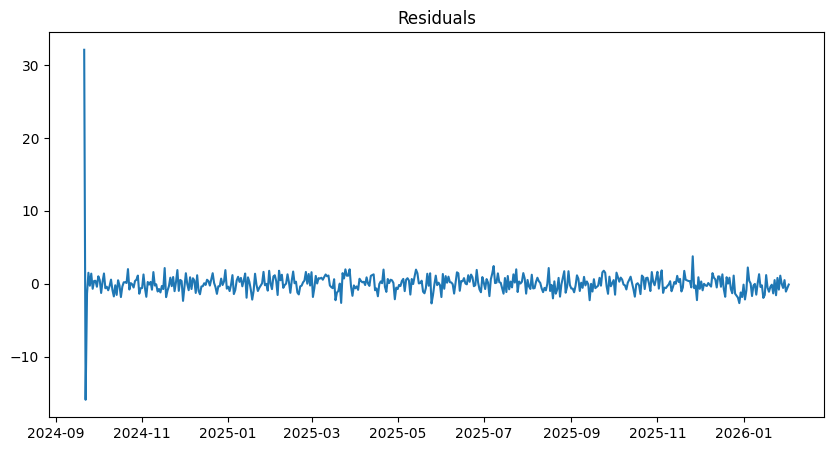

In [ ]:
# Residual Analysis
# Residual Plot
residuals = best_model.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

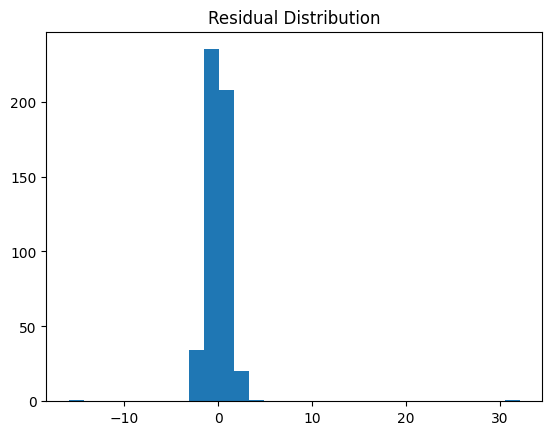

In [ ]:
# Residual Distribution
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

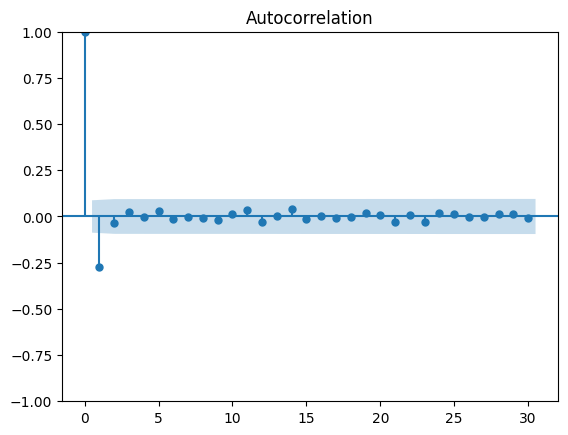

In [ ]:
# Residual ACF
plot_acf(residuals, lags=30)
plt.show()

In [ ]:
# Model Evaluation (RMSE)
pred = best_model.fittedvalues

rmse = np.sqrt(mean_squared_error(df['price'][1:], pred[1:]))

print("RMSE:", rmse)

RMSE: 1.222915637640207


In [ ]:
# Forecast 24 Months
forecast_steps = 730

forecast = best_model.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()

forecast_index = pd.date_range(start=df.index[-1], periods=forecast_steps+1, freq='D')[1:]

forecast_series = pd.Series(forecast.predicted_mean.values, index=forecast_index)

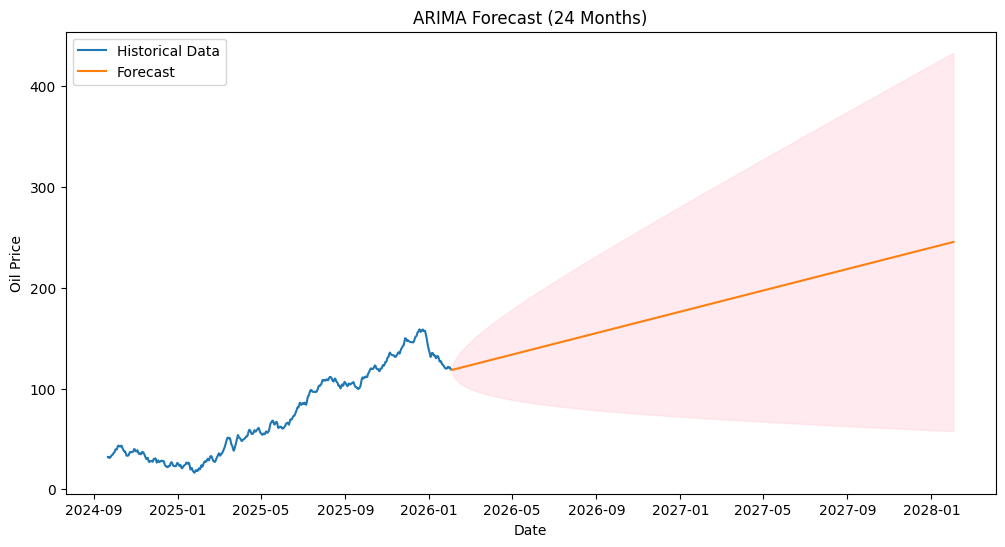

In [ ]:
# Plot Forecast with Confidence Intervals
plt.figure(figsize=(12,6))

plt.plot(df.index, df['price'], label="Historical Data")
plt.plot(forecast_series.index, forecast_series, label="Forecast")

plt.fill_between(forecast_index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='pink', alpha=0.3)

plt.title("ARIMA Forecast (24 Months)")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()

plt.show()

# **PART 2 — Alternative Model (Prophet)**

In [ ]:
# Prepare Data for Prophet
df_prophet = df.reset_index()

df_prophet = df_prophet.rename(columns={
    'date':'ds',
    'price':'y'
})

print(df_prophet.head())

          ds      y  diff_price
0 2024-09-21  32.10         NaN
1 2024-09-22  32.25        0.15
2 2024-09-23  31.07       -1.18
3 2024-09-24  31.50        0.43
4 2024-09-25  32.21        0.71


In [ ]:
# Train Prophet Model
model = Prophet()

model.fit(df_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Create Future Dataframe
future = model.make_future_dataframe(periods=730)

forecast_prophet = model.predict(future)

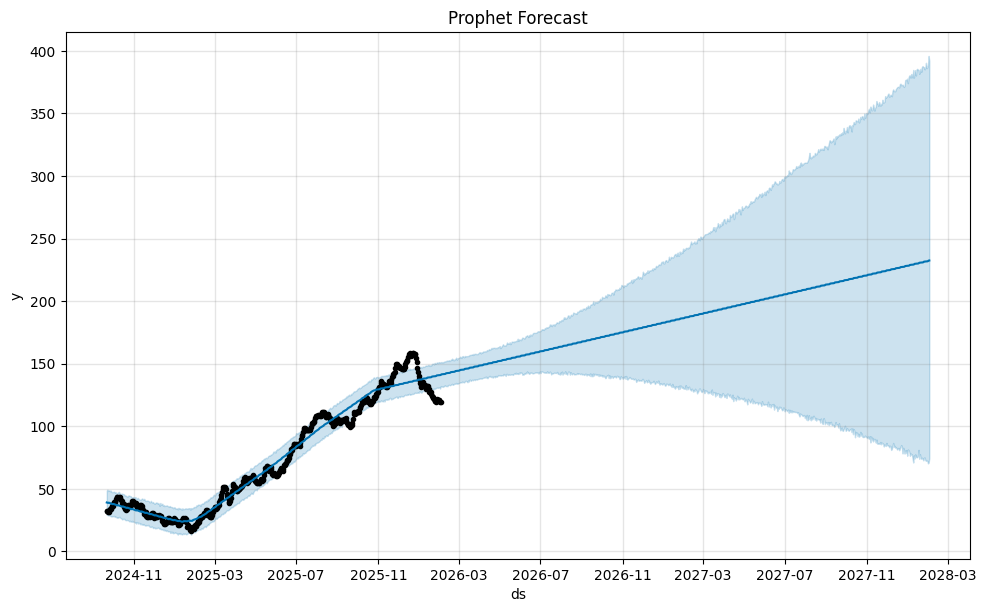

In [ ]:
# Prophet Forecast Plot
fig = model.plot(forecast_prophet)
plt.title("Prophet Forecast")
plt.show()

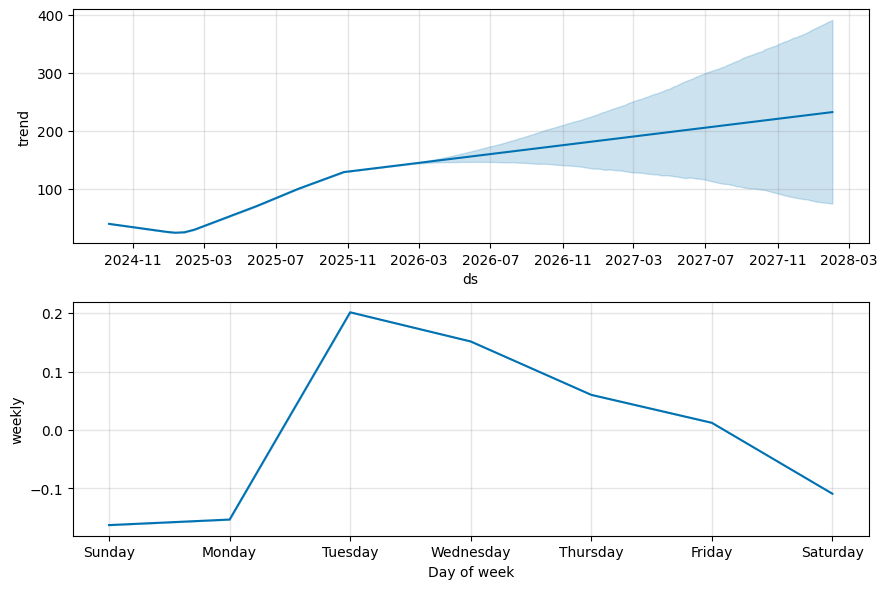

In [ ]:
# Prophet Components
fig = model.plot_components(forecast_prophet)
plt.show()

In [ ]:
# Prophet RMSE
prophet_pred = forecast_prophet['yhat'][:len(df)]

rmse_prophet = np.sqrt(mean_squared_error(df['price'], prophet_pred))

print("Prophet RMSE:", rmse_prophet)

Prophet RMSE: 7.732001203766893


In [ ]:
# Model Comparison
print("ARIMA RMSE:", rmse)
print("Prophet RMSE:", rmse_prophet)

ARIMA RMSE: 1.222915637640207
Prophet RMSE: 7.732001203766893
